# Campus Placement Eligibility Predictor — Exploratory Data Analysis

This notebook explores the dataset used to train the placement eligibility model:
- Distribution of features (CGPA, skills, internships, projects)
- Class balance (eligible vs not eligible)
- Relationships between features and the target
- Correlations between all variables
- Feature engineering preview


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data.csv")
df.head()

,cgpa,skills,internships,projects,eligible
0,5.99,1,0,5,0
1,6.94,2,1,1,0
2,9.20,0,0,3,0
3,8.99,0,0,5,0
4,6.75,1,1,3,0


## 1. Dataset Overview

In [2]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe()

Shape: (200, 5)

Missing values:
 cgpa           0
skills         0
internships    0
projects       0
eligible       0
dtype: int64

Duplicate rows: 1


,cgpa,skills,internships,projects,eligible
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,7.455350,2.590000,1.495000,3.415000,0.335000
std,1.434182,1.684067,1.138621,1.638965,0.473175
min,5.030000,0.000000,0.000000,1.000000,0.000000
25%,6.190000,1.000000,0.000000,2.000000,0.000000
50%,7.525000,3.000000,2.000000,3.000000,0.000000
75%,8.665000,4.000000,3.000000,5.000000,1.000000
max,9.930000,5.000000,3.000000,6.000000,1.000000


## 2. Target Class Balance

eligible
0    133
1     67
Name: count, dtype: int64


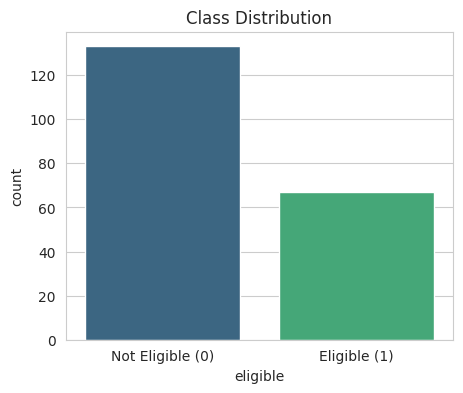

In [3]:
counts = df["eligible"].value_counts().sort_index()
print(counts)

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x="eligible", hue="eligible", data=df, palette="viridis", legend=False, ax=ax)
ax.set_xticks([0,1])
ax.set_xticklabels(["Not Eligible (0)", "Eligible (1)"])
ax.set_title("Class Distribution")
plt.show()

## 3. Feature Distributions

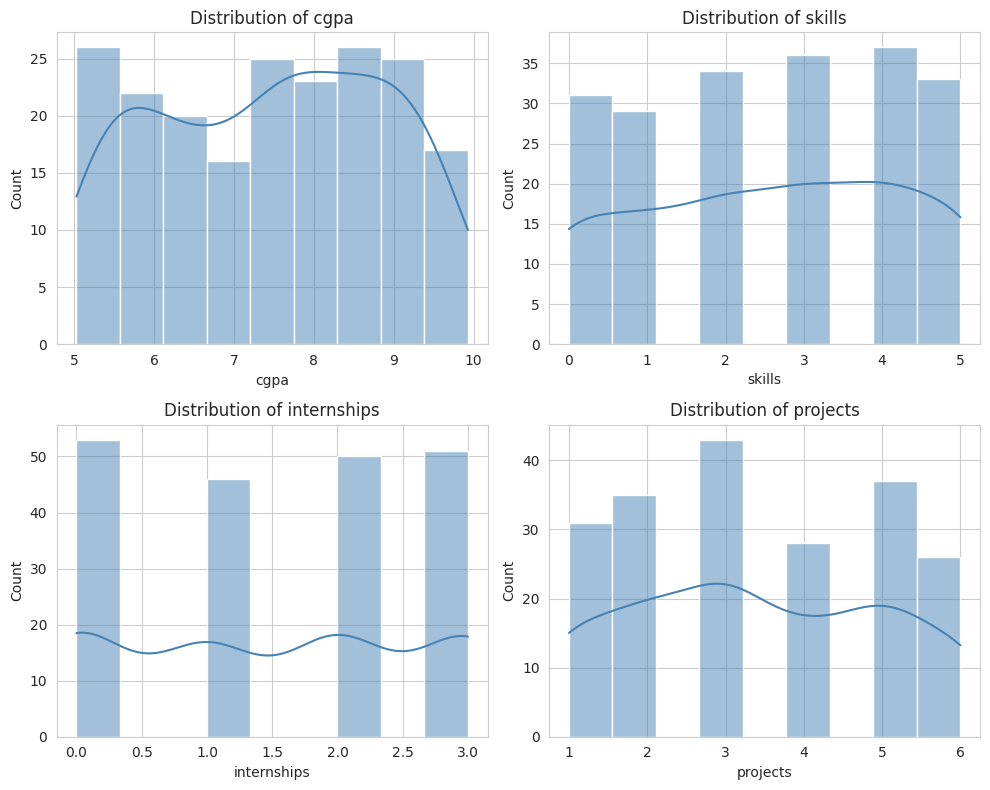

In [4]:
numeric_cols = ["cgpa", "skills", "internships", "projects"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## 4. CGPA vs Eligibility

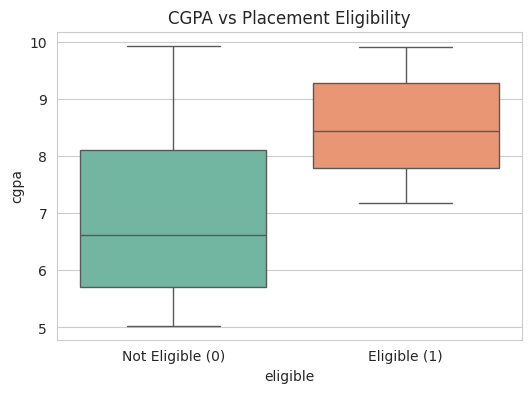

Average CGPA (Eligible): 8.48
Average CGPA (Not Eligible): 6.94


In [5]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x="eligible", y="cgpa", hue="eligible", data=df, palette="Set2", legend=False, ax=ax)
ax.set_xticks([0,1])
ax.set_xticklabels(["Not Eligible (0)", "Eligible (1)"])
ax.set_title("CGPA vs Placement Eligibility")
plt.show()

print("Average CGPA (Eligible):", df[df.eligible==1]["cgpa"].mean().round(2))
print("Average CGPA (Not Eligible):", df[df.eligible==0]["cgpa"].mean().round(2))

## 5. Eligibility Rate by Skills / Internships / Projects

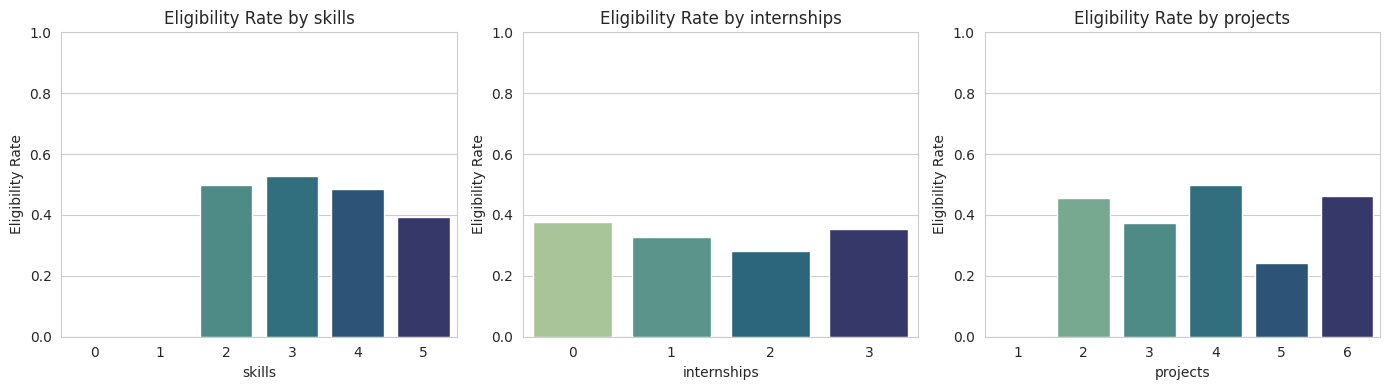

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, ["skills", "internships", "projects"]):
    rate = df.groupby(col)["eligible"].mean()
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette="crest", legend=False, ax=ax)
    ax.set_ylabel("Eligibility Rate")
    ax.set_title(f"Eligibility Rate by {col}")
    ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

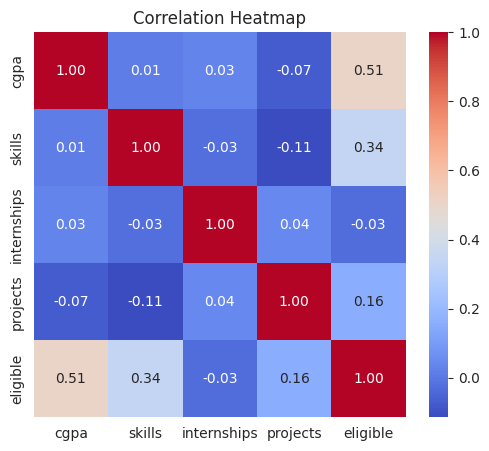

In [7]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

## 7. Pairwise Relationships

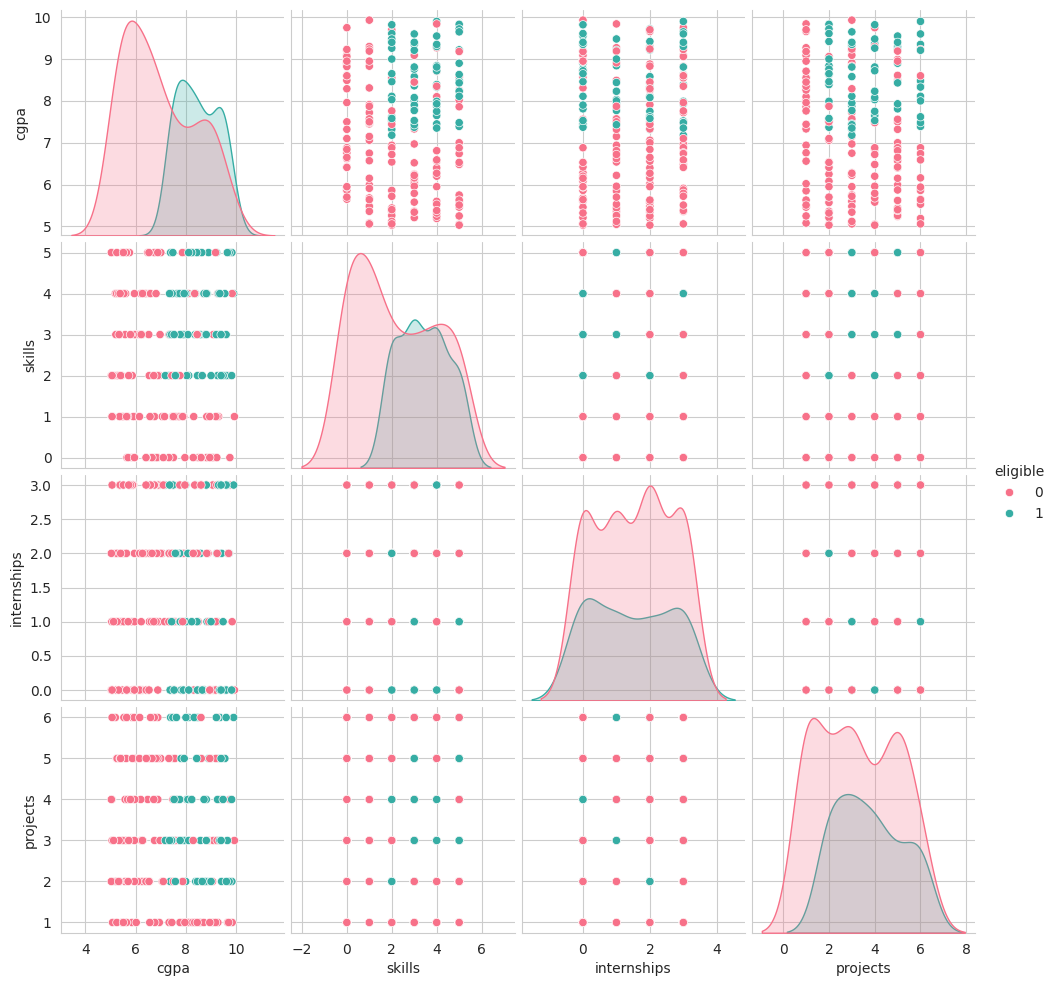

In [8]:
sns.pairplot(df, vars=numeric_cols, hue="eligible", palette="husl", diag_kind="kde")
plt.show()

## 8. Feature Engineering Preview

Three new features are created before training:

- **experience_score** = skills + internships + projects
- **cgpa_band** = categorical CGPA bucket (Low / Medium / High)
- **cgpa_experience_interaction** = cgpa * experience_score


In [9]:
from features import add_engineered_features

df_fe = add_engineered_features(df)
df_fe.head()

,cgpa,skills,internships,projects,eligible,experience_score,cgpa_band,cgpa_experience_interaction
0,5.99,1,0,5,0,6,0,35.94
1,6.94,2,1,1,0,4,1,27.76
2,9.20,0,0,3,0,3,2,27.60
3,8.99,0,0,5,0,5,2,44.95
4,6.75,1,1,3,0,5,1,33.75


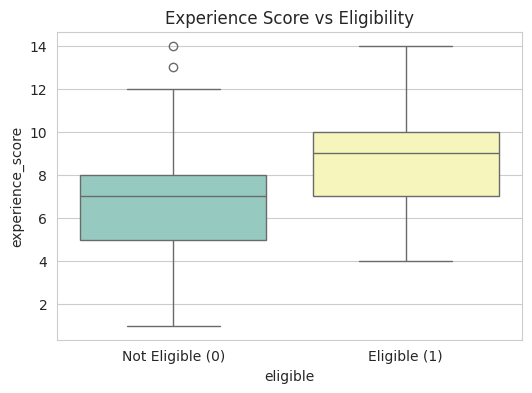

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x="eligible", y="experience_score", hue="eligible", data=df_fe,
            palette="Set3", legend=False, ax=ax)
ax.set_xticks([0,1])
ax.set_xticklabels(["Not Eligible (0)", "Eligible (1)"])
ax.set_title("Experience Score vs Eligibility")
plt.show()

## 9. Key Takeaways

- The dataset has **200 rows** and is moderately imbalanced (more "Not Eligible" examples).
- **CGPA** has the strongest individual correlation with placement eligibility.
- **Skills, internships, and projects** individually show weaker but still
  meaningful trends — combining them into an `experience_score` captures
  overall practical exposure.
- No single feature perfectly separates eligible vs not-eligible students,
  which supports using a multi-feature model like Random Forest rather than
  a simple rule-based threshold.
- See `train_model.py` for the model training and evaluation step, and
  `metrics.txt` / `plots/` for evaluation results.
